# LAYER 2: MULTIMODAL FUSION, MODALITY WEIGHTING & MODEL BENCHMARKING

# Importing all libreries

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
)
from sklearn.feature_selection import SelectFromModel

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

# 1. Mount Google Drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. File Paths

In [ ]:
base_dir = '/content/drive/MyDrive/Thesis/Dataset'
text_file   = os.path.join(base_dir, 'mentalbert_features_768d.npy')
voice_file  = os.path.join(base_dir, 'voice_covarep_processed.csv')
visual_file = os.path.join(base_dir, 'visual_au_processed.csv')
master_file = os.path.join(base_dir, 'results_master_stacked.csv')

# 3. Load Processed Unimodal Datasets & Master Metadata

In [ ]:
df_text   = pd.DataFrame(np.load(text_file))
df_voice  = pd.read_csv(voice_file)
df_visual = pd.read_csv(visual_file)
df_master = pd.read_csv(master_file)

In [ ]:
df_meta = df_master[['participant_id', 'phq8_binary', 'phq8_score', 'split_set']].drop_duplicates()

# 4. Multimodal Fusion via participant_id

In [ ]:
df_text['participant_id'] = df_meta['participant_id']

df_fused = df_text.merge(df_voice, on='participant_id', how='inner')
df_fused = df_fused.merge(df_visual, on='participant_id', how='inner')
df_fused = df_fused.merge(df_meta, on='participant_id', how='inner')

print(f"Fused dataset shape: {df_fused.shape}")

Fused dataset shape: (139, 797)


# 5. Identify Modality Feature Blocks

In [ ]:
text_cols   = [c for c in df_text.columns if c != 'participant_id']
voice_cols  = [c for c in df_voice.columns if c != 'participant_id']
visual_cols = [c for c in df_visual.columns if c != 'participant_id']

print(f"Features: Text={len(text_cols)}, Voice={len(voice_cols)}, Visual={len(visual_cols)}")

Features: Text=768, Voice=11, Visual=14


---

# 6. ADJUSTABLE MODALITY WEIGHTS (Human-in-the-Loop Attention Mask)

In [ ]:
EXPERIMENT_CONFIGS = {
    # Unimodal Baselines
    "Text Only":       {'w_text': 1.0, 'w_voice': 0.0, 'w_visual': 0.0},
    "Voice Only":      {'w_text': 0.0, 'w_voice': 1.0, 'w_visual': 0.0},
    "Visual Only":     {'w_text': 0.0, 'w_voice': 0.0, 'w_visual': 1.0},
    # Bimodal Synergies
    "Text + Voice":    {'w_text': 1.0, 'w_voice': 1.0, 'w_visual': 0.0},
    "Text + Visual":   {'w_text': 1.0, 'w_voice': 0.0, 'w_visual': 1.0},
    "Voice + Visual":  {'w_text': 0.0, 'w_voice': 1.0, 'w_visual': 1.0},
    # Trimodal Early Fusion Baseline (1:1:1)
    "Trimodal Fusion": {'w_text': 1.0, 'w_voice': 1.0, 'w_visual': 1.0},
    # HITL Survey-Weighted Model (Hypothesis 2)
    "HITL Survey-Weighted": {'w_text': 0.328, 'w_voice': 0.354, 'w_visual': 0.318}
}

#7. Split Train vs Test Sets (Preserving DAIC-WOZ Benchmark Splits)

In [ ]:
train_mask = df_fused['split_set'].str.lower().isin(['train', 'training'])
test_mask  = df_fused['split_set'].str.lower().isin(['test', 'dev', 'validation'])

y_train = df_fused.loc[train_mask, 'phq8_binary'].astype(int)
y_test  = df_fused.loc[test_mask, 'phq8_binary'].astype(int)

# 8. Define the 3 Benchmark Classifiers

In [ ]:
classifiers = {
    "Logistic Regression (L2 Regularized)": LogisticRegression(
        C=0.1, penalty='l2', solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=42
    ),
    "Support Vector Machine (RBF Kernel)": SVC(
        C=1.0, kernel='rbf', probability=True, class_weight='balanced', random_state=42
    ),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_split=4, class_weight='balanced', random_state=42
    )
}

# 9. Train, Predict, and Evaluate

In [ ]:
benchmark_records = []

for exp_name, weights in EXPERIMENT_CONFIGS.items():
    print(f"Running Experiment: {exp_name}...")

    df_temp = df_fused.copy()
    df_temp[text_cols]   = df_temp[text_cols] * weights['w_text']
    df_temp[voice_cols]  = df_temp[voice_cols] * weights['w_voice']
    df_temp[visual_cols] = df_temp[visual_cols] * weights['w_visual']

    active_features = []
    if weights['w_text'] > 0:   active_features += text_cols
    if weights['w_voice'] > 0:  active_features += voice_cols
    if weights['w_visual'] > 0: active_features += visual_cols

    X_train = df_temp.loc[train_mask, active_features]
    X_test  = df_temp.loc[test_mask, active_features]

    X_train.columns = X_train.columns.astype(str)
    X_test.columns = X_test.columns.astype(str)

    # --- HYPOTHESIS 1 INTERVENTION: FEATURE OPTIMIZATION ---
    if len(active_features) > 50:
        print(f"  -> Applying L1 Feature Selection to {len(active_features)} initial variables...")
        selector = SelectFromModel(
            LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)
        )
        X_train_selected = selector.fit_transform(X_train, y_train)
        X_test_selected  = selector.transform(X_test)
        selected_count = X_train_selected.shape[1]
        print(f"  -> Features reduced to {selected_count} high-relevance variables.")
    else:
        X_train_selected = X_train.values
        X_test_selected  = X_test.values
        selected_count = len(active_features)

    for clf_name, clf in classifiers.items():
        clf.fit(X_train_selected, y_train)
        y_pred = clf.predict(X_test_selected)
        y_proba = clf.predict_proba(X_test_selected)[:, 1] if hasattr(clf, 'predict_proba') else None

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        auc  = roc_auc_score(y_test, y_proba) if y_proba is not None and len(np.unique(y_test)) > 1 else np.nan

        benchmark_records.append({
            'Experiment': exp_name,
            'Original_Features': len(active_features),
            'Selected_Features': selected_count,
            'Model': clf_name,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(auc, 4) if not np.isnan(auc) else "N/A"
        })

df_results = pd.DataFrame(benchmark_records)
df_results.to_csv(os.path.join(base_dir, 'multimodal_experiment_results_H1_optimized.csv'), index=False)

print("\n" + "="*90)
print("ALL BENCHMARK TESTS COMPLETE (WITH FEATURE OPTIMIZATION & CLASS BALANCING)")
print("="*90)
print(df_results.to_markdown(index=False))

Running Experiment: Text Only...
  -> Applying L1 Feature Selection to 768 initial variables...
  -> Features reduced to 4 high-relevance variables.
Running Experiment: Voice Only...
Running Experiment: Visual Only...
Running Experiment: Text + Voice...
  -> Applying L1 Feature Selection to 779 initial variables...
  -> Features reduced to 12 high-relevance variables.
Running Experiment: Text + Visual...
  -> Applying L1 Feature Selection to 782 initial variables...
  -> Features reduced to 11 high-relevance variables.
Running Experiment: Voice + Visual...
Running Experiment: Trimodal Fusion...
  -> Applying L1 Feature Selection to 793 initial variables...
  -> Features reduced to 19 high-relevance variables.
Running Experiment: HITL Survey-Weighted...
  -> Applying L1 Feature Selection to 793 initial variables...
  -> Features reduced to 11 high-relevance variables.

ALL BENCHMARK TESTS COMPLETE (WITH FEATURE OPTIMIZATION & CLASS BALANCING)
| Experiment           |   Original_Features

---

# FINAL STEP: EXTRACT FEATURE IMPORTANCE (Answering Sub-Q2 & Sub-Q3)

## 1. Isolate the HITL configuration and prepare the active feature space

In [ ]:
hitl_weights = EXPERIMENT_CONFIGS["HITL Survey-Weighted"]
df_hitl = df_fused.copy()

df_hitl[text_cols]   = df_hitl[text_cols] * hitl_weights['w_text']
df_hitl[voice_cols]  = df_hitl[voice_cols] * hitl_weights['w_voice']
df_hitl[visual_cols] = df_hitl[visual_cols] * hitl_weights['w_visual']

all_active_features = text_cols + voice_cols + visual_cols
X_train_hitl = df_hitl.loc[train_mask, all_active_features]
X_train_hitl.columns = X_train_hitl.columns.astype(str)

## 2. Re-fit the L1 Selector to get the boolean mask of surviving features

In [ ]:
l1_selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)
)
l1_selector.fit(X_train_hitl, y_train)
surviving_feature_mask = l1_selector.get_support()
surviving_feature_names = np.array(all_active_features)[surviving_feature_mask]

## 3. Fit Logistic Regression to extract the directional coefficients (Impact)

In [ ]:
final_lr = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', class_weight='balanced', random_state=42)
X_train_selected = l1_selector.transform(X_train_hitl)
final_lr.fit(X_train_selected, y_train)

coefficients = final_lr.coef_[0]

## 4. Map features back to their source modalities

In [ ]:
text_cols_str   = [str(c) for c in text_cols]
voice_cols_str  = [str(c) for c in voice_cols]
visual_cols_str = [str(c) for c in visual_cols]

modality_labels = []
for feature in surviving_feature_names:
    f_str = str(feature)
    if f_str in text_cols_str:
        modality_labels.append("Text (MentalBERT)")
    elif f_str in voice_cols_str:
        modality_labels.append("Voice (COVAREP)")
    else:
        modality_labels.append("Visual (Action Units)")

## 5. Create a structured dataframe

In [ ]:
df_importance = pd.DataFrame({
    'Feature_Name': surviving_feature_names,
    'Modality': modality_labels,
    'Coefficient': coefficients,
    'Absolute_Impact': np.abs(coefficients)
}).sort_values(by='Absolute_Impact', ascending=False)


Top 11 Features Driving the Multimodal Predictions:
| Feature_Name   | Modality              |   Coefficient |
|:---------------|:----------------------|--------------:|
| H1H2_mean      | Voice (COVAREP)       |    0.276391   |
| Rd_std         | Voice (COVAREP)       |    0.253887   |
| NAQ_std        | Voice (COVAREP)       |    0.187039   |
| AU02_r_std     | Visual (Action Units) |   -0.176682   |
| Rd_mean        | Voice (COVAREP)       |    0.176385   |
| AU12_r_std     | Visual (Action Units) |   -0.1591     |
| peakSlope_std  | Voice (COVAREP)       |    0.151119   |
| AU04_r_mean    | Visual (Action Units) |    0.120459   |
| AU15_r_std     | Visual (Action Units) |   -0.099331   |
| F0_std         | Voice (COVAREP)       |   -0.0747073  |
| 308            | Text (MentalBERT)     |    0.00341056 |


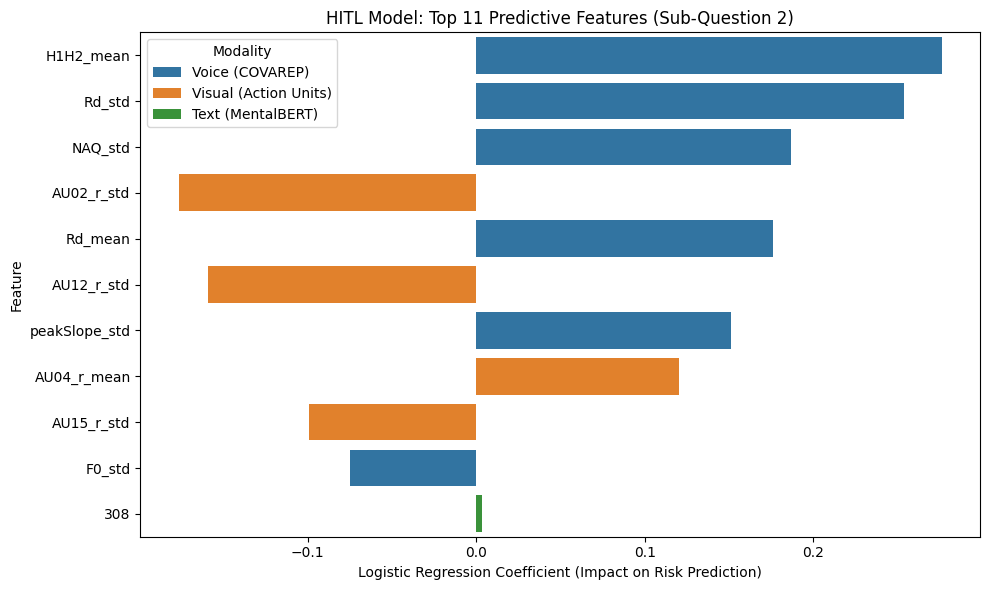

In [ ]:
importance_csv_path = os.path.join(base_dir, 'hitl_feature_importance.csv')
df_importance.to_csv(importance_csv_path, index=False)

print("\nTop 11 Features Driving the Multimodal Predictions:")
print(df_importance[['Feature_Name', 'Modality', 'Coefficient']].to_markdown(index=False))
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature_Name', hue='Modality', data=df_importance, dodge=False)
plt.title("HITL Model: Top 11 Predictive Features (Sub-Question 2)")
plt.xlabel("Logistic Regression Coefficient (Impact on Risk Prediction)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'feature_importance_plot.png'), dpi=300)
plt.show()

## Summary

This notebook presents a multimodal fusion approach for depression detection, integrating text, voice, and visual features. The pipeline begins with loading pre-processed unimodal datasets (MentalBERT text features, COVAREP voice features, and Action Units visual features) along with master metadata containing participant IDs and PHQ-8 scores.

Multimodal fusion is performed by merging these datasets based on `participant_id`. Adjustable modality weights, including unimodal baselines, bimodal synergies, trimodal fusion (1:1:1), and a Human-in-the-Loop (HITL) survey-weighted model, are defined for experimentation.

The data is then split into training and testing sets, preserving the DAIC-WOZ benchmark splits. Three benchmark classifiers (Logistic Regression, Support Vector Machine, and Random Forest Classifier) are defined.

For each experiment configuration, the features are weighted, and L1 feature selection is applied to reduce dimensionality for high-dimensional modalities. The classifiers are trained on the selected features, and performance metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) are calculated and recorded.

Finally, the notebook focuses on extracting feature importance from the HITL survey-weighted model. An L1 selector is re-fit to identify surviving features, and a Logistic Regression model is used to extract directional coefficients. These coefficients are mapped back to their source modalities (Text, Voice, Visual) to identify and visualize the top predictive features driving the multimodal predictions.